In [2]:
import sys
import os
import numpy as np
import pandas as pd
from typing import  Optional, Callable, Dict
from collections.abc import Mapping
import re, unicodedata

sys.path.append(os.path.abspath('..'))
from core.s3 import S3AssetManager

from core.viz import (
        plot_gauge_grid,
        plot_bar,
        plot_heatmap,
        plot_pie,
        plot_time_heatmap,
        plot_line,
        plot_corr_triangle,
        plot_statistical_strip,
        plot_scatter,
)

In [3]:
notebook_name = "okuo__eficiencia__planta"
s3 = S3AssetManager(notebook_name=notebook_name)

In [4]:


def limpiar_nombres_operarios(serie):
    # 1. ESTANDARIZACIÓN BÁSICA
    # Convierte a texto, quita espacios al inicio/final y pasa a Título (Juan Perez)
    serie_limpia = serie.astype(str).str.strip().str.title()
    
    # 2. LIMPIEZA DE "RUIDO" (Valores nulos disfrazados)
    # Convertimos guiones, 'Nan', 'Null' a un valor nulo real (NaN) o una categoría
    valores_nulos = ['-', 'Nan', 'Null', 'None', '']
    serie_limpia = serie_limpia.replace(valores_nulos, np.nan)
    
    # 3. CORRECCIÓN DE TYPOS (Diccionario de Generalización)
    # Mapeamos los errores comunes a la versión correcta
    correcciones = {
        'Robison': 'Robinson',  # Corrigiendo falta de 'n'
        'Albeiro .': 'Albeiro', # Por si hay puntos
        'Jhon': 'John',         # Estandarizando grafía (si fuera el caso)
        # Agrega aquí nuevos errores que aparezcan en el futuro
    }
    
    serie_limpia = serie_limpia.replace(correcciones)
    
    return serie_limpia



def imputar_outliers_con_mediana(df, columna, p_min=0.01, p_max=0.97):
    """
    Detecta valores fuera de los rangos (percentiles) y los reemplaza por la mediana.
    
    Parámetros:
    df (pd.DataFrame): Tu dataframe.
    columna (str): Nombre de la columna a limpiar.
    p_min (float): Percentil inferior (0.01 = 1%).
    p_max (float): Percentil superior (0.97 = 97%).
    """
    # 1. Calcular límites
    limite_inferior = df[columna].quantile(p_min)
    limite_superior = df[columna].quantile(p_max)
    mediana = df[columna].median()
    mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    df.loc[mask_outliers, columna] = mediana
    
    return df


In [5]:
bd_feeds = pd.read_excel("../raw/BD PRODUCCION FEEDS .xlsx", sheet_name="DATOS")

In [6]:
bd_feeds = bd_feeds.rename(columns={16923: 'lote'})

In [7]:
bd_feeds.columns

Index(['lote', 'MES', 'Fecha programacion', 'Fecha Fabricacion', 'NOMBRE',
       'ESPECIE', 'ETAPA', 'SILO ORIGEN', 'SILO DESTINO', 'HORA INICIO',
       'HORA FINAL', 'TIEMPO', 'Horas', 'VAPOR(PSI)', 'CARGA (HZ)',
       'TEMP. (ºc)', 'DUREZA', 'DURABILIDAD ENFRIADOR', 'DURABILIDAD ENSAQUE',
       'TON PELETIZADAS', 'TON/HORA', 'Peletizador', 'SACK OFF (%)',
       'HUMEDAD (%)', 'BULTOS ', 'DIFERENCIA '],
      dtype='object')

In [8]:
new_columns = {
    # Identificadores y Tiempo
    'lote': 'lot',
    'MES': 'month',
    'Fecha programacion': 'scheduled_date',
    'Fecha Fabricacion': 'production_date',
    'HORA INICIO': 'start_time',
    'HORA FINAL': 'end_time',
    'TIEMPO': 'duration_str',      # Asumiendo que es texto "HH:MM"
    'Horas': 'duration_hours',     # Asumiendo que es número

    # Producto y Logística
    'NOMBRE': 'feed_type',
    'ESPECIE': 'species',
    'ETAPA': 'production_stage',
    'SILO ORIGEN': 'silo_source',
    'SILO DESTINO': 'silo_dest',
    
    # Variables de Proceso (Críticas para tu análisis de pérdidas)
    'VAPOR(PSI)': 'steam_psi',
    'CARGA (HZ)': 'load_hz',
    'TEMP. (ºc)': 'temperature_c',
    'Peletizador': 'pelletizer_operator', # O 'pelletizer_machine' según corresponda

    # Calidad y Métricas
    'DUREZA': 'hardness',
    'DURABILIDAD ENFRIADOR': 'durability_cooler',
    'DURABILIDAD ENSAQUE': 'durability_bagging',
    'HUMEDAD (%)': 'moisture_pct',
    'SACK OFF (%)': 'sack_off_pct',

    # Rendimiento / Producción
    'TON PELETIZADAS': 'quantity_produced_tm',
    'TON/HORA': 'performance_tph',  # TPH = Ton per Hour (Estándar industrial)
    'BULTOS ': 'bags_count',
    'DIFERENCIA ': 'variance'
}

# Aplicar el cambio
lots = bd_feeds.rename(columns=new_columns)
lots = lots[lots["lot"].notnull()]
lots["source"] = "bd_feeds"

In [9]:
dates = ['scheduled_date', 'production_date']
for date in dates:
    lots[date] = pd.to_datetime(lots[date], errors='coerce')

cols_process_measurements = [
    'silo_source', 'silo_dest','duration_hours',
    'steam_psi', 'load_hz',
    'temperature_c', 'hardness', 
    'durability_cooler', 'durability_bagging',
    'quantity_produced_tm', 'performance_tph',
    'sack_off_pct', 'moisture_pct',
    ]

for col in cols_process_measurements:
    lots[col] = pd.to_numeric(lots[col], errors='coerce')

lots['lot'] = lots['lot'].astype(int)


lots['pelletizer_operator'] = limpiar_nombres_operarios(lots['pelletizer_operator'])
lots['pelletizer_operator']  = lots['pelletizer_operator'].fillna('Unknown_feeds')


lots.loc[lots['durability_cooler'] > 100, 'durability_cooler'] = lots['durability_cooler'].median()
lots.loc[(lots['moisture_pct'] < 8) |(lots['moisture_pct'] >13), 'moisture_pct'] = lots['moisture_pct'].median()

lots = imputar_outliers_con_mediana(lots, 'performance_tph', p_min=0.01, p_max=0.99)
lots = imputar_outliers_con_mediana(lots, 'sack_off_pct', p_min=0.01, p_max=0.99)


In [10]:
cols_utis = [

'lot',
'production_date',
'feed_type',

'steam_psi',
'load_hz',
'temperature_c',

'hardness',
'durability_cooler',
'durability_bagging',
'moisture_pct',

'duration_hours',
'quantity_produced_tm',
'performance_tph',

'pelletizer_operator',
'sack_off_pct',

'source'
]

In [11]:
lots[cols_utis]

,lot,production_date,feed_type,steam_psi,load_hz,temperature_c,hardness,durability_cooler,durability_bagging,moisture_pct,duration_hours,quantity_produced_tm,performance_tph,pelletizer_operator,sack_off_pct,source
0,13197,2024-05-01,Leche lita,70.0,19.0,65.0,2.8,96.8,NaN,NaN,0.766667,8.0,10.434783,Unknown_feeds,NaN,bd_feeds
1,13198,2024-05-01,Tropico bajo,70.0,19.0,65.0,NaN,NaN,NaN,NaN,0.400000,4.0,10.000000,Unknown_feeds,NaN,bd_feeds
2,13203,2024-05-01,Levante Provimi,70.0,19.0,65.0,2.9,96.4,NaN,NaN,4.033333,42.0,10.413223,Unknown_feeds,NaN,bd_feeds
3,13200,2024-05-01,Alfa Show,70.0,17.5,65.0,4.2,98.7,NaN,NaN,1.450000,12.0,8.275862,Unknown_feeds,NaN,bd_feeds
4,13201,2024-05-01,Alfa media,70.0,19.0,65.0,3.9,95.6,NaN,NaN,1.200000,6.0,5.000000,Unknown_feeds,NaN,bd_feeds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3830,17043,2026-01-10,NaN,70.0,26.0,70.0,NaN,95.2,NaN,NaN,1.866667,16.0,8.571429,Albeiro,NaN,bd_feeds
3831,17044,2026-01-10,NaN,70.0,18.0,70.0,NaN,94.8,NaN,NaN,1.700000,16.0,9.411765,Albeiro,NaN,bd_feeds
3832,17035,2026-01-10,CERDO LEVANTE TIERRALEGRE,70.0,26.0,70.0,NaN,94.2,NaN,NaN,1.233333,10.0,8.108108,Robinson,NaN,bd_feeds
3833,17045,2026-01-10,NaN,70.0,18.5,70.0,NaN,94.0,NaN,NaN,0.916667,8.0,8.727273,Robinson,NaN,bd_feeds


In [12]:
plot_statistical_strip(
    df=lots,
    x_col='source',
    y_col='steam_psi'
)

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

<Figure size 1500x1000 with 0 Axes>

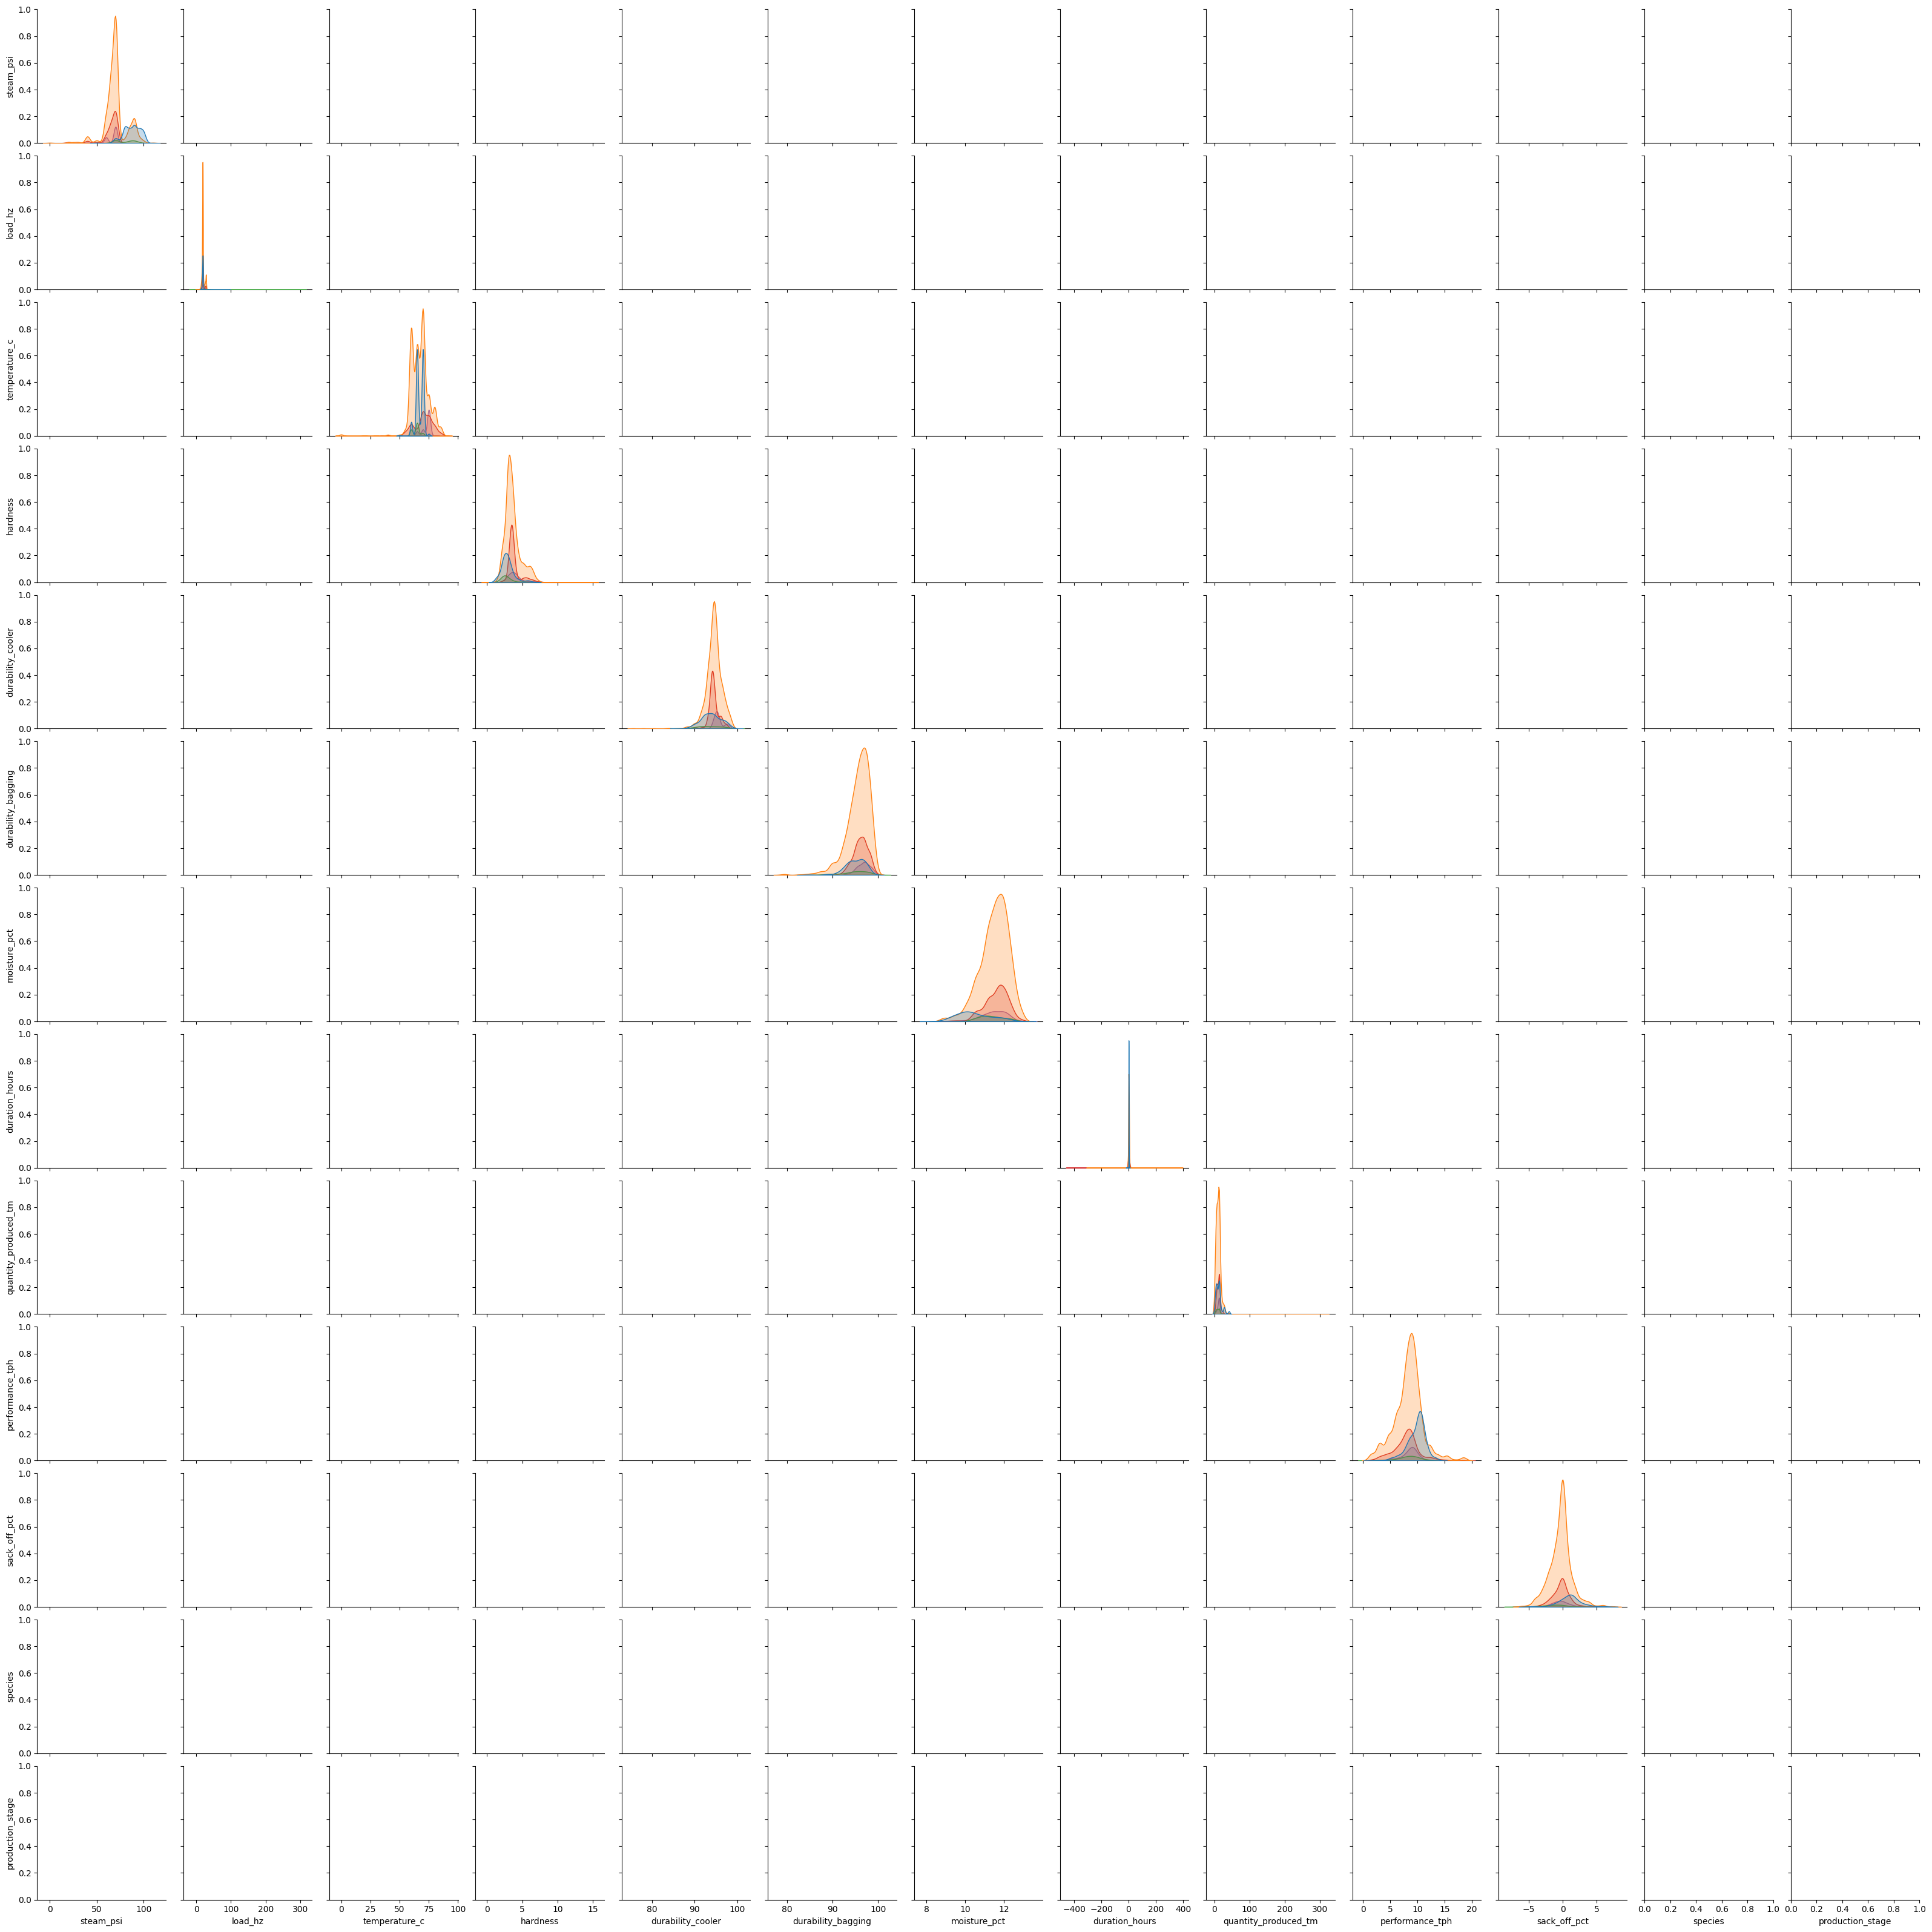

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos solo las columnas de interés
# Es importante no meter TODAS las columnas o el gráfico será ilegible
cols_interes = [
'steam_psi',
'load_hz',
'temperature_c',

'hardness',
'durability_cooler',
'durability_bagging',
'moisture_pct',

'duration_hours',
'quantity_produced_tm',
'performance_tph',
'sack_off_pct',

 'species',
 'production_stage',

]

# 2. Filtrado opcional: Quedarnos con los Top 5 operarios
# Si tienes 20 operarios, el gráfico será un arcoíris confuso. Mejor ver los principales.
top_operarios = lots['pelletizer_operator'].value_counts().nlargest(5).index
df_plot = lots[lots['pelletizer_operator'].isin(top_operarios)].copy()

# 3. Crear el Pairplot
plt.figure(figsize=(15, 10))
sns.pairplot(
    df_plot, 
    vars=cols_interes,       # Las variables numéricas a cruzar
    hue='pelletizer_operator', # Colorear por operario
    palette='tab10',         # Colores distintivos
    diag_kind='kde',         # Usar curvas suaves en la diagonal en vez de barras
    plot_kws={'alpha': 0.6}  # Transparencia para ver puntos superpuestos
)

plt.suptitle("Análisis de Variables de Proceso por Operario", y=1.02, fontsize=16)
plt.show()

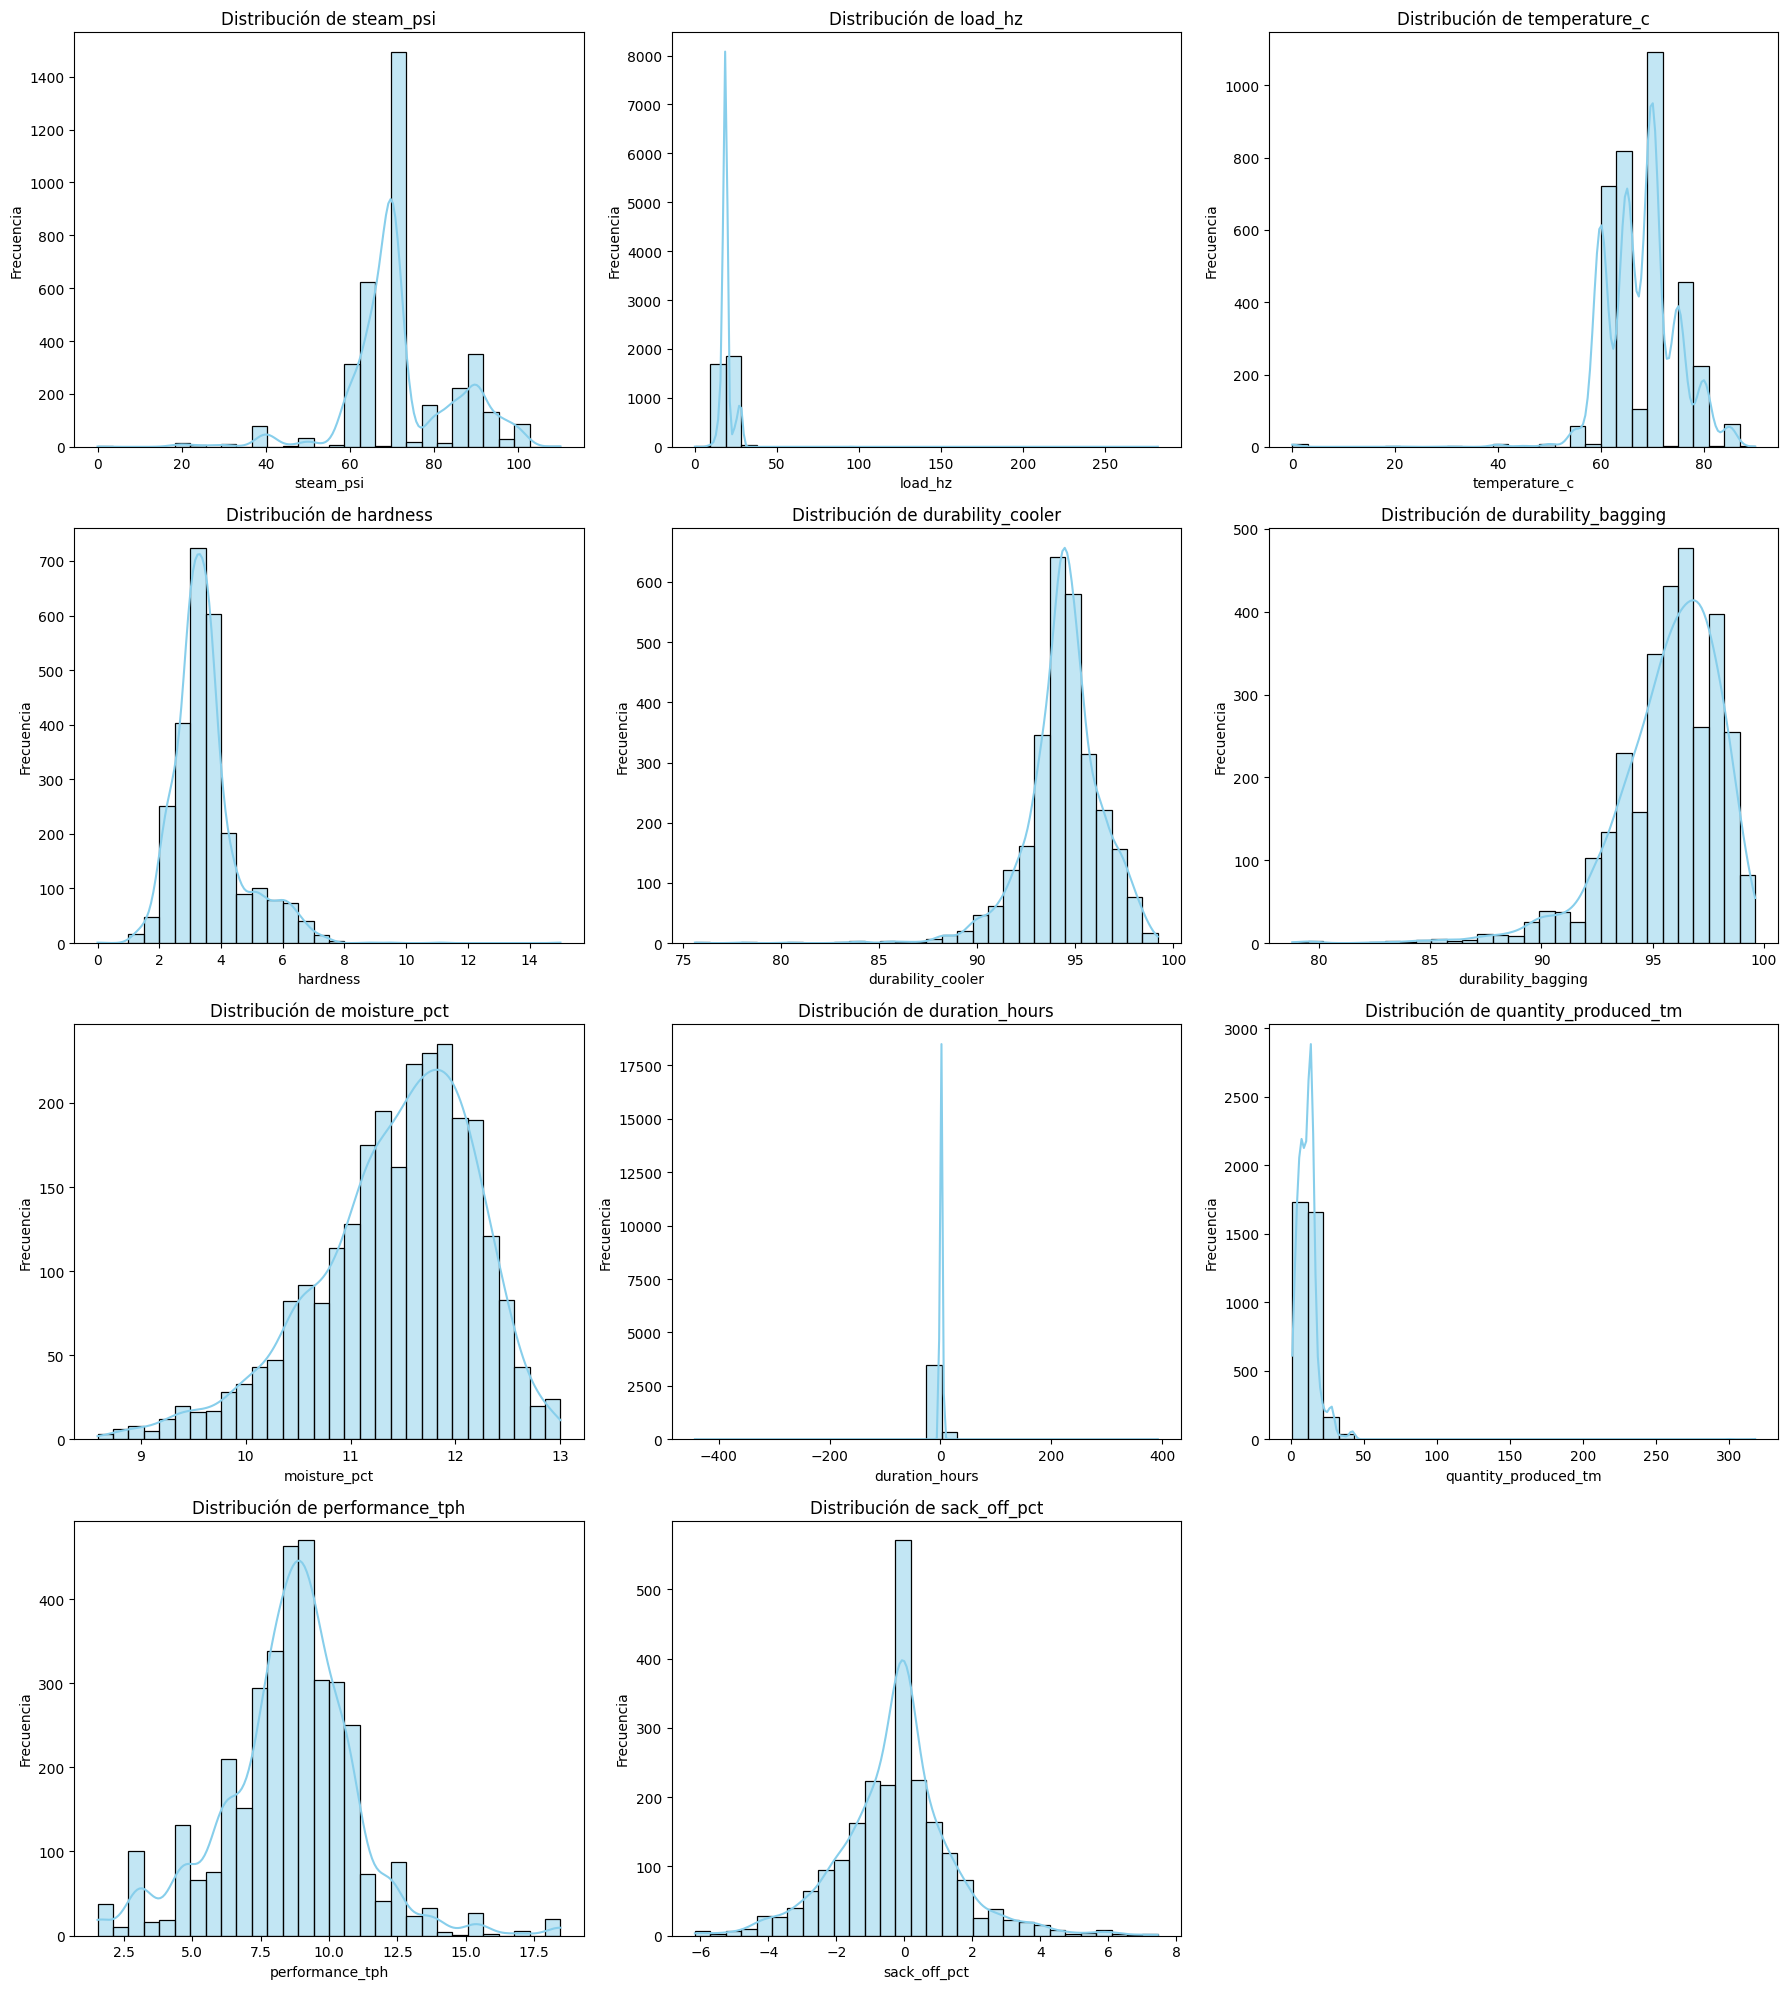

In [ ]:

import math

# 1. Definimos las columnas numéricas que queremos analizar
columnas_analisis = [
'steam_psi',
'load_hz',
'temperature_c',

'hardness',
'durability_cooler',
'durability_bagging',
'moisture_pct',

'duration_hours',
'quantity_produced_tm',
'performance_tph',
'sack_off_pct',
]

# 2. Configuración del panel de gráficos (Grid)
n_cols = 3  # Número de gráficos por fila
n_rows = math.ceil(len(columnas_analisis) / n_cols)

plt.figure(figsize=(18, 5 * n_rows)) # Ajustamos el tamaño dinámicamente

# 3. Bucle para generar cada gráfico
for i, col in enumerate(columnas_analisis):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Creamos el histograma con la curva de densidad (KDE)
    # hue='pelletizer_operator' es opcional: quítalo si quieres ver la distribución general
    sns.histplot(data=lots, x=col, kde=True, bins=30, color='skyblue', edgecolor='black')
    
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
db_aliforte = s3.read_csv("data/aliforte_production/aliforte_production.csv")
db_aliforte["source"] = 'bd_aliforte'

In [ ]:
db_aliforte

,lot,pellet,production_date,feed_type,specie,start_time,quantity_produced_tm,duration_hours,temperature_c,rows,...,product,moisture_pct,durability_bagging,quantity_reprocess_kg,feed_type_reprocess,responsable,reprocess_cause,quantity_reprocess_tm,tiro,source
0,313,pellet 3,2025-09-10,BCE,cerdos,16:00:00,15.0,3.166667,81.3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,corto,bd_aliforte
1,21296,pellet 2,2025-09-01,E-1,broiler,14:00:00,30.0,5.916667,77.1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,largo,bd_aliforte
2,21530,pellet 3,2025-10-08,BCG,cerdos,12:00:00,5.0,0.750000,80.3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,corto,bd_aliforte
3,30190,pellet 1,2025-09-17,E-1,broiler,07:30:00,30.0,5.250000,84.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,largo,bd_aliforte
4,30431,pellet 1,2025-09-23,HY-2,reproductoras,14:25:00,2.0,1.083333,80.3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,corto,bd_aliforte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,31840,pellet 3,2023-11-28,E-4,broiler,11:05:00,20.0,0.000000,82.8,1,...,APE4,12.89,96.23,NaN,NaN,NaN,NaN,NaN,largo,bd_aliforte
723,31842,pellet 1,2025-11-28,BAI,ponedora,14:10:00,10.0,0.000000,NaN,1,...,BAI,11.52,98.83,NaN,NaN,NaN,NaN,NaN,corto,bd_aliforte
724,31844,pellet 3,2025-11-28,PCR,maquila,16:50:00,1.0,0.000000,75.0,1,...,InCR,11.99,98.38,NaN,NaN,NaN,NaN,NaN,corto,bd_aliforte
725,31845,pellet 2,2025-11-28,PF-02,cerdos,18:40:00,10.0,0.000000,61.6,1,...,PF02,9.61,98.07,NaN,NaN,NaN,NaN,NaN,corto,bd_aliforte


In [ ]:
rename = {
    'date': 'production_date',
    'pdi': 'durability_bagging',
    'hum': 'moisture_pct',
    'hour': 'duration_hours',
    'quantity_tm': 'quantity_produced_tm',
    'performance': 'performance_tph',
    'operators': 'pelletizer_operator',
    'specie': 'species',
}
db_aliforte = db_aliforte.rename(columns=rename)

cols_utis_alifort = [
 'lot',
 'production_date',
 'feed_type',
 'species',
 
 'temperature_c',
 'durability_bagging',
 'moisture_pct',
 'duration_hours',
 'quantity_produced_tm',
 'performance_tph',
 'pelletizer_operator',
 'source'

]

db_aliforte_filter = db_aliforte[cols_utis_alifort].copy()
db_aliforte_filter

,lot,production_date,feed_type,species,temperature_c,durability_bagging,moisture_pct,duration_hours,quantity_produced_tm,performance_tph,pelletizer_operator,source
0,313,2025-09-10,BCE,cerdos,81.3,NaN,NaN,3.166667,15.0,4.736842,Jose Benalcazar,bd_aliforte
1,21296,2025-09-01,E-1,broiler,77.1,NaN,NaN,5.916667,30.0,5.070423,Jose Cabezas,bd_aliforte
2,21530,2025-10-08,BCG,cerdos,80.3,NaN,NaN,0.750000,5.0,6.666667,Jose Cabezas,bd_aliforte
3,30190,2025-09-17,E-1,broiler,84.0,NaN,NaN,5.250000,30.0,5.714286,Jose Benalcazar,bd_aliforte
4,30431,2025-09-23,HY-2,reproductoras,80.3,NaN,NaN,1.083333,2.0,1.846154,Jose Benalcazar,bd_aliforte
...,...,...,...,...,...,...,...,...,...,...,...,...
722,31840,2023-11-28,E-4,broiler,82.8,96.23,12.89,0.000000,20.0,NaN,Brayan Erazo,bd_aliforte
723,31842,2025-11-28,BAI,ponedora,NaN,98.83,11.52,0.000000,10.0,NaN,Johnny Tirira,bd_aliforte
724,31844,2025-11-28,PCR,maquila,75.0,98.38,11.99,0.000000,1.0,NaN,Jose Cabezas,bd_aliforte
725,31845,2025-11-28,PF-02,cerdos,61.6,98.07,9.61,0.000000,10.0,NaN,Jose Cabezas,bd_aliforte


In [24]:
supa = pd.read_csv("../raw/bd_supa.csv")

In [25]:
supa["die_number"].value_counts()

die_number
4.5      2418
3.0       112
2.5        93
5          32
5.0        20
5.5        18
4.0         7
3           4
4           3
2           3
405.0       1
4,,5        1
Name: count, dtype: int64

In [26]:
supa_dado = supa[supa["die_number"].notnull()]
supa_dado.columns

Index(['lot', 'source', 'production_date', 'die_number', 'pelletizer_operator',
       'adiflow', 'species', 'feed_type', 'pellet', 'quantity_produced_tm',
       'init_time', 'end_time', 'end_hourmeter', 'init_hourmeter',
       'temperature_c', 'load_hz', 'steam_psi', 'durability_cooler', 'sackoff',
       'pdi'],
      dtype='object')

In [ ]:
supa_dado[['init_time', 'end_time','end_hourmeter',
'init_hourmeter', ]]

array([nan], dtype=object)

In [30]:
supa[supa["init_time"].notnull()]

,lot,source,production_date,die_number,pelletizer_operator,adiflow,species,feed_type,pellet,quantity_produced_tm,init_time,end_time,end_hourmeter,init_hourmeter,temperature_c,load_hz,steam_psi,durability_cooler,sackoff,pdi
0,81401,Raza,2024-08-14,NaN,Andres Mejia,False,NaN,Raza cuido,Pellet 1,18.0,00:00:00,05:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,91101,Raza,2024-09-11,NaN,Andres Mejia,False,NaN,Ponedora 18% medicada,Pellet 1,8.0,00:00:00,01:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82001,Raza,2025-08-21,NaN,Heliberto Saenz,True,NaN,Raza cuido,Pellet 1,16.0,00:00:00,02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,90201,Raza,2024-09-02,NaN,Hitan Gaitan,False,NaN,Utmost engorde rac granel,Pellet 1,8.0,00:00:00,01:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,121201,Raza,2024-12-12,NaN,Hitan Gaitan,False,NaN,Utmost engorde rac granel,Pellet 1,8.0,00:00:00,02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30857,51701,Raza,2024-05-17,NaN,Hitan Gaitan,False,NaN,Super pollitas,Pellet 2 y 3,8.0,00:00:00,01:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30858,50201,Raza,2025-05-02,NaN,Hitan Gaitan,True,NaN,Cerdo nueva raza gestacion,Pellet 2 y 3,6.0,00:00:00,00:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30859,52601,Raza,2025-05-27,NaN,Hitan Gaitan,True,NaN,Preiniciador fase 2 pmx,Pellet 2 y 3,4.0,00:00:00,00:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30861,41701,Raza,2024-04-18,NaN,Andres Mejia,False,NaN,Reproductora machos ross biomix,Pellet 2 y 3,27.0,00:00:00,05:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
